## Porto Seguro Safe Driver Prediction - EDA

In [47]:
# Bibliothek laden und Setup einrichten

# Dateien und Ordner verwalten
from pathlib import Path

# Data-Stack
import numpy as np
import pandas as pd

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns

# Datensatz-Loader für OpenML
from sklearn.datasets import fetch_openml

In [48]:
# Ergebnisse reproduzieren

RANDOM_STATE = 42 # feste Zufallszahl 

In [49]:
# Daten laden 
ds = fetch_openml(data_id=42742, as_frame=True, parser="auto")
train = ds.frame.rename(columns={ds.target.name: "target"})

# target kommt aus dem ARFF als Kategorie/String -> auf 0/1 int bringen
train["target"] = train["target"].astype(int)

print(f"train: {train.shape[0]:>8,} Zeilen x {train.shape[1]:>3} Spalten")

train:  595,212 Zeilen x  58 Spalten


In [50]:
train.head()          # die ersten fünf Zeilen ansehen

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,2.0,2,5.0,1,0,0,1,0,0,...,9.0,1.0,5.0,8.0,0,1,1,0,0,1
1,0,1.0,1,7.0,0,0,0,0,1,0,...,3.0,1.0,1.0,9.0,0,1,1,0,1,0
2,0,5.0,4,9.0,1,0,0,0,1,0,...,4.0,2.0,7.0,7.0,0,1,1,0,1,0
3,0,0.0,1,2.0,0,0,1,0,0,0,...,2.0,2.0,4.0,9.0,0,0,0,0,0,0
4,0,0.0,2,0.0,1,0,1,0,0,0,...,3.0,1.0,1.0,3.0,0,0,0,1,1,0


In [51]:
train.info()          # Datentypen und Speicherbedarf

<class 'pandas.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 58 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   target          595212 non-null  int64   
 1   ps_ind_01       595212 non-null  float64 
 2   ps_ind_02_cat   594996 non-null  category
 3   ps_ind_03       595212 non-null  float64 
 4   ps_ind_04_cat   595129 non-null  category
 5   ps_ind_05_cat   589403 non-null  category
 6   ps_ind_06_bin   595212 non-null  category
 7   ps_ind_07_bin   595212 non-null  category
 8   ps_ind_08_bin   595212 non-null  category
 9   ps_ind_09_bin   595212 non-null  category
 10  ps_ind_10_bin   595212 non-null  category
 11  ps_ind_11_bin   595212 non-null  category
 12  ps_ind_12_bin   595212 non-null  category
 13  ps_ind_13_bin   595212 non-null  category
 14  ps_ind_14       595212 non-null  float64 
 15  ps_ind_15       595212 non-null  float64 
 16  ps_ind_16_bin   595212 non-null  category
 17  ps

In [52]:
train.describe().T    # Kennzahlen aller numerischen Spalten 

,count,mean,std,min,25%,50%,75%,max
target,595212.0,0.036448,0.187401,0.000000,0.000000,0.000000,0.000000,1.000000
ps_ind_01,595212.0,1.900378,1.983789,0.000000,0.000000,1.000000,3.000000,7.000000
ps_ind_03,595212.0,4.423318,2.699902,0.000000,2.000000,4.000000,6.000000,11.000000
ps_ind_14,595212.0,0.012451,0.127545,0.000000,0.000000,0.000000,0.000000,4.000000
ps_ind_15,595212.0,7.299922,3.546042,0.000000,5.000000,7.000000,10.000000,13.000000
ps_reg_01,595212.0,0.610991,0.287643,0.000000,0.400000,0.700000,0.900000,0.900000
ps_reg_02,595212.0,0.439184,0.404264,0.000000,0.200000,0.300000,0.600000,1.800000
ps_reg_03,487440.0,0.894047,0.345413,0.061237,0.633443,0.801561,1.083974,4.037945
ps_car_11,595207.0,2.346100,0.832495,0.000000,2.000000,3.000000,3.000000,3.000000
ps_car_12,595211.0,0.379947,0.058300,0.100000,0.316228,0.374166,0.400000,1.264911


In [60]:
# dubletten checken

n_dupes = train.duplicated().sum()

print(f"Dubletten: {n_dupes:,} von {len(train):,} Zeilen "
      f"({n_dupes / len(train):.2%})")

Dubletten: 0 von 595,212 Zeilen (0.00%)


# Namensschema der Features

Präfixe:

- Ind - Merkmal zum Individuum (Fahrer)
- Reg - Regionsbezogen
- Car - Merkmal zum Fahrzeug
- Calc - berechnete (abgeleitete) Merkmale
- “ps” steht einfach nur für “Porto Seguro” 

Postfixe:

- -bin - binäres Feature (0/1)
- -cat - kategoriales Feature
- (kein Postfix) - kontinuierliche oder ordinales Feature

In [5]:
def build_meta(df: pd.DataFrame) -> pd.DataFrame:
    """Leitet Rolle, Skalenniveau und Gruppe jedes Features aus dem Namen ab."""
    rows = []
    for col in df.columns:
        # Rolle im Modell
        if col == "target":
            role = "target"
        elif col == "id":
            role = "id"
        else:
            role = "input"

        # Skalenniveau: erst über den Namen (Suffix), dann über die Werte
        if col in ("id", "target"):
            level = col
        elif col.endswith("bin"):
            level = "binary"       # 0/1
        elif col.endswith("cat"):
            level = "nominal"      # Kategorie (ungeordnet)
        elif pd.api.types.is_numeric_dtype(df[col]):
            nn = df[col].dropna()  # NaN macht int-Spalten zu float -> Werte prüfen, nicht Dtype
            level = "interval" if (nn % 1 != 0).any() else "ordinal"
        else:
            level = "nominal"      # numerisch nicht -> als Kategorie behandeln

        # Feature-Gruppe: ind / reg / car / calc
        group = col.split("_")[1] if col.startswith("ps_") else "meta"

        rows.append({
            "varname": col,
            "role": role,
            "level": level,
            "group": group,
            "dtype": str(df[col].dtype),
            "n_missing": int(df[col].isna().sum()),   # ist jetzt NaN, nicht -1
            "n_unique": int(df[col].nunique()),
        })
    return pd.DataFrame(rows).set_index("varname")

meta = build_meta(train)
meta.head(12)

,role,level,group,dtype,n_missing,n_unique
varname,,,,,,
target,target,target,meta,int64,0,2
ps_ind_01,input,ordinal,ind,float64,0,8
ps_ind_02_cat,input,nominal,ind,category,216,4
ps_ind_03,input,ordinal,ind,float64,0,12
ps_ind_04_cat,input,nominal,ind,category,83,2
ps_ind_05_cat,input,nominal,ind,category,5809,7
ps_ind_06_bin,input,binary,ind,category,0,2
ps_ind_07_bin,input,binary,ind,category,0,2
ps_ind_08_bin,input,binary,ind,category,0,2


In [6]:
bin_cols = meta[meta.level == "binary"].index.tolist()
cat_cols = meta[meta.level == "nominal"].index.tolist()
num_cols = meta[meta.level.isin(["interval", "ordinal"])].index.tolist()

# Überblick: wie viele Features je Gruppe und Skalenniveau?
meta.query("role == 'input'").groupby(["group", "level"]).size().unstack(fill_value=0)

level,binary,interval,nominal,ordinal
group,,,,
calc,6,3,0,11
car,0,4,11,1
ind,11,0,3,4
reg,0,3,0,0


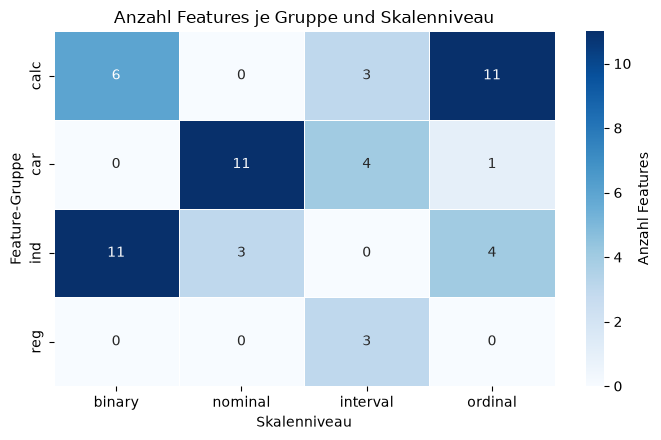

In [7]:
# Kreuztabelle group x level (selbst berechnet -> keine Abhängigkeit von anderen Zellen)
ct = (meta.query("role == 'input'")
          .groupby(["group", "level"]).size()
          .unstack(fill_value=0))
level_order = [l for l in ["binary", "nominal", "interval", "ordinal"] if l in ct.columns]
ct = ct[level_order]

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", linewidths=.5, linecolor="white",
            cbar_kws={"label": "Anzahl Features"}, ax=ax)
ax.set_title("Anzahl Features je Gruppe und Skalenniveau")
ax.set_xlabel("Skalenniveau"); ax.set_ylabel("Feature-Gruppe")
plt.tight_layout(); plt.show()

target
0    573518
1     21694
Name: count, dtype: int64
target
0    96.355
1     3.645
Name: proportion, dtype: float64


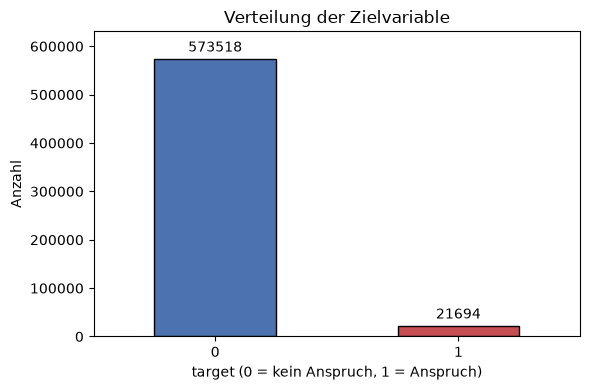

Anteil positiver Klasse: 3.6448%


In [38]:
# target - Verteilung

counts = train["target"].value_counts().sort_index()
share = train["target"].value_counts(normalize=True).sort_index()

print(counts)
print((share * 100).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(
    kind="bar", 
    ax=ax, 
    color=["#4C72B0", "#C44E52"], 
    edgecolor="black")
# balkenbeschriftung
ax.bar_label(ax.containers[0], padding=3)
# padding für die zahlen
ax.set_ylim(0, counts.max() * 1.1)

ax.set_title("Verteilung der Zielvariable")
ax.set_xlabel("target (0 = kein Anspruch, 1 = Anspruch)")
ax.set_ylabel("Anzahl")
ax.set_xticklabels(["0", "1"], rotation=0)
plt.tight_layout()
plt.show()

print(f"Anteil positiver Klasse: {train['target'].mean():.4%}")

In [ ]:
# Fehlende Werte
# in der openML-Version sind fehlende Werte als NaN codiert (nicht mehr als -1).
# Anzahl und Anteil der fehlenden Werte pro Feature bestimmen.

missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "count_missing": missing,
    "percent_missing": (missing / len(train) * 100).round(2),
})
missing_df

,count_missing,percent_missing
ps_car_03_cat,411231,69.09
ps_car_05_cat,266551,44.78
ps_reg_03,107772,18.11
ps_car_14,42620,7.16
ps_car_07_cat,11489,1.93
ps_ind_05_cat,5809,0.98
ps_car_09_cat,569,0.10
ps_ind_02_cat,216,0.04
ps_car_01_cat,107,0.02
ps_ind_04_cat,83,0.01


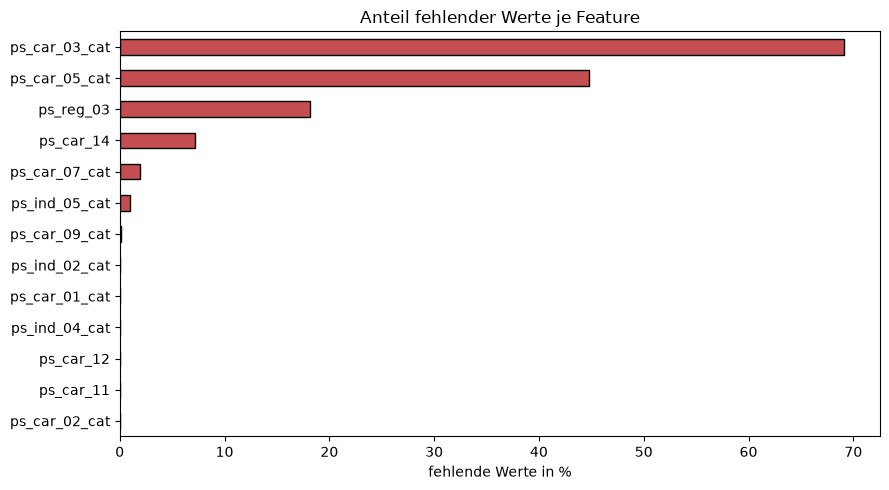

In [ ]:
# Visualisierung

fig, ax = plt.subplots(figsize=(9, 5))
missing_df["percent_missing"].sort_values().plot(kind="barh", ax=ax, color="#C44E52", edgecolor="black")
ax.set_title("Anteil fehlender Werte je Feature")
ax.set_xlabel("fehlende Werte in %")
plt.tight_layout()
plt.show()


In [11]:
# Anzahl fehlender Werte je Zeile 

n_missing_per_row = train.isna().sum(axis=1)
n_missing_per_row.describe()

count    595212.000000
mean          1.422112
std           0.940689
min           0.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           8.000000
dtype: float64

In [ ]:
# Hängt die Anzahl fehlender Werte je Zeile mit dem Ziel zusammen?
n_missing_per_row = train.drop(columns="target").isna().sum(axis=1)

print(n_missing_per_row.groupby(train["target"]).mean()
      .rename("mittlere Fehlwerte je Zeile"))

by_n = (pd.DataFrame({"n_miss": n_missing_per_row, "target": train["target"]})
        .groupby("n_miss")["target"].agg(target_rate="mean", n="count"))
by_n[by_n["n"] >= 1000]

target
0    1.426689
1    1.301097
Name: mittlere Fehlwerte je Zeile, dtype: float64


,target_rate,n
n_miss,,
0,0.045385,124931
1,0.036348,156295
2,0.034014,254982
3,0.028015,56042
4,0.023240,2883


# Univariate Analyse - jedes Feature für sich

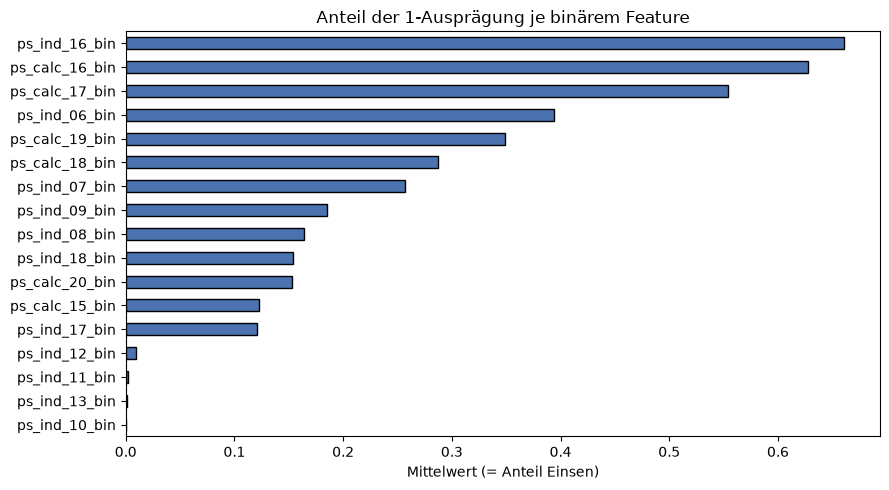

In [ ]:
# binäre Features (Mittelwert ist Anteil an einsen)

bin_means = train[bin_cols].apply(pd.to_numeric, errors="coerce").mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bin_means.plot(kind="barh", ax=ax, color="#4C72B0", edgecolor="black")
ax.set_title("Anteil der 1-Ausprägung je binärem Feature")   
ax.set_xlabel("Mittelwert (= Anteil Einsen)")
plt.tight_layout()
plt.show()

In [14]:
# Kardinalität: wie viele verschied. Kategorien hat jedes _cat-Feature

cat_card = train[cat_cols].nunique().sort_values(ascending=False)
cat_card

ps_car_11_cat    104
ps_car_06_cat     18
ps_car_01_cat     12
ps_car_04_cat     10
ps_ind_05_cat      7
ps_car_09_cat      5
ps_ind_02_cat      4
ps_car_10_cat      3
ps_ind_04_cat      2
ps_car_02_cat      2
ps_car_03_cat      2
ps_car_05_cat      2
ps_car_07_cat      2
ps_car_08_cat      2
dtype: int64

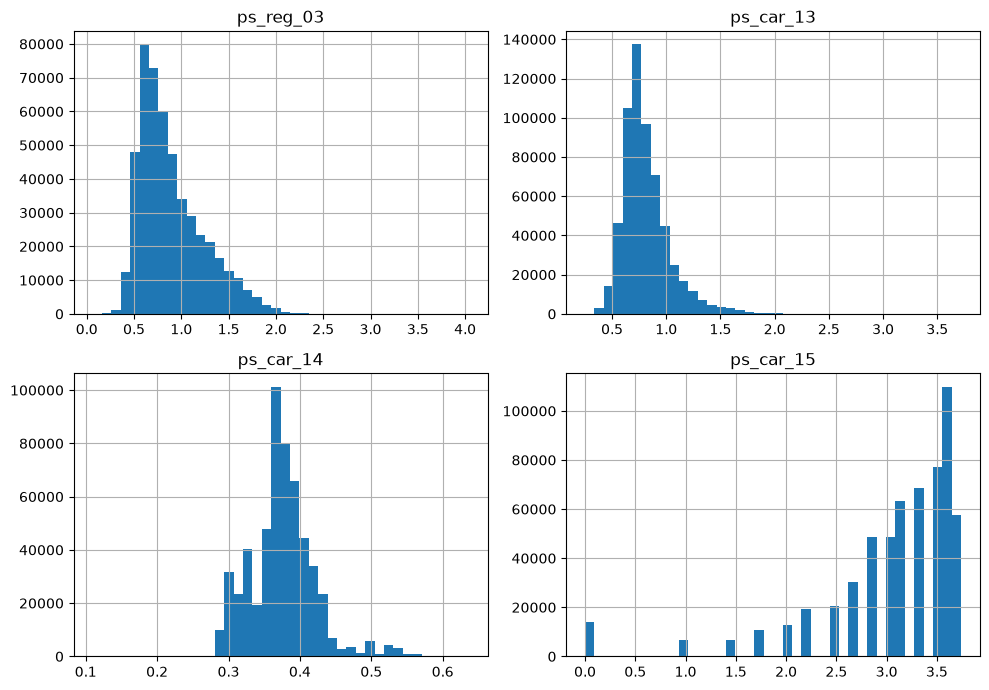

In [15]:
# ordinale und numerische Features
train[num_cols].describe().T

# beispielhafte Verteilungen
cols_to_plot = ["ps_reg_03", "ps_car_13", "ps_car_14", "ps_car_15"]

train[cols_to_plot].hist(bins=40, figsize=(10, 7))
plt.tight_layout()
plt.show()

# Bivariate Analyse

In [16]:
# numerisches Feature vs. target
num_corr = (train[num_cols]
            .corrwith(train["target"])
            .abs()
            .sort_values(ascending=False))
num_corr.head(15)

ps_car_13     0.053899
ps_car_12     0.038800
ps_reg_02     0.034800
ps_reg_03     0.033758
ps_car_15     0.027667
ps_reg_01     0.022888
ps_ind_15     0.021506
ps_ind_01     0.018570
ps_car_14     0.011674
ps_ind_03     0.008360
ps_ind_14     0.007443
ps_calc_03    0.001907
ps_calc_01    0.001782
ps_calc_14    0.001362
ps_calc_02    0.001360
dtype: float64

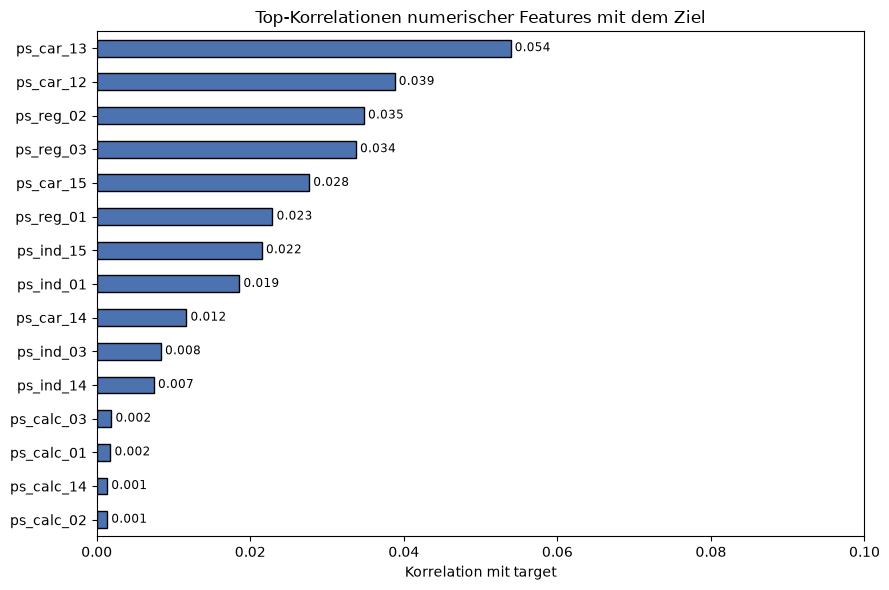

In [41]:
# Visualisierung von numerisches Feature vs. target

num_corr = train[num_cols].corrwith(train["target"]).abs().sort_values(ascending=False)
top = num_corr.head(15).sort_values()

ax = top.plot(kind="barh", figsize=(9, 6), color="#4C72B0", edgecolor="black")
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3, fontsize=8.5)   
ax.set_xlim(0, 0.10)
ax.set_xlabel("Korrelation mit target")
ax.set_title("Top-Korrelationen numerischer Features mit dem Ziel")
plt.tight_layout(); plt.show()

In [18]:
# kategoriales feature vs. target

def target_rate_by_category(df, col, target="target"):
    """Anspruchsrate und Häufigkeit je Kategorie eines Features."""
    grp = (df.groupby(col, observed=True)[target]
              .agg(target_rate="mean", n="count")
              .sort_values("target_rate", ascending=False))
    return grp

target_rate_by_category(train, "ps_ind_05_cat")

,target_rate,n
ps_ind_05_cat,,
2,0.075526,4184
6,0.059336,20662
4,0.052061,18344
5,0.048514,1649
1,0.047825,8322
3,0.042998,8233
0,0.033865,528009


In [19]:
# Variante, die die fehlenden Werte als eigene Gruppe mit anzeigt:
train.groupby("ps_ind_05_cat", observed=True, dropna=False)["target"] \
     .agg(target_rate="mean", n="count").sort_values("target_rate", ascending=False)

,target_rate,n
ps_ind_05_cat,,
NaN,0.083319,5809
2,0.075526,4184
6,0.059336,20662
4,0.052061,18344
5,0.048514,1649
1,0.047825,8322
3,0.042998,8233
0,0.033865,528009


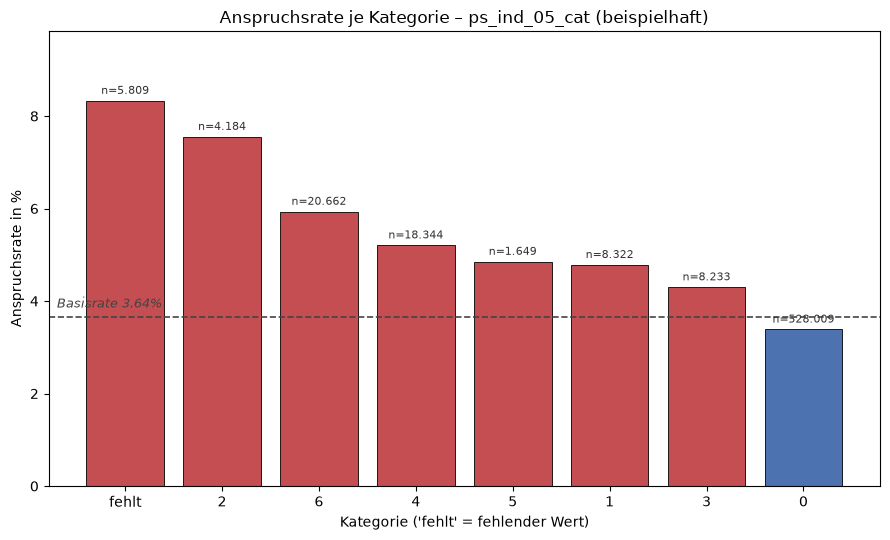

In [44]:
# visualisierung des kategorialen feature vs. target

col  = "ps_ind_05_cat"
rates = (train.groupby(col, observed=True, dropna=False)["target"]
              .agg(target_rate="mean", n="count")
              .sort_values("target_rate", ascending=False))
base = train["target"].mean()

# NaN (fehlend) als lesbares Label 
xlabels = [("fehlt" if pd.isna(i) else str(i)) for i in rates.index]

colors = np.where(rates["target_rate"] >= base, "#C44E52", "#4C72B0")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(xlabels, rates["target_rate"] * 100,
       color=colors, edgecolor="black", linewidth=0.6)

ax.axhline(base * 100, ls="--", color="#444", lw=1.2)
ax.text(0.01, base * 100 + 0.15, f"Basisrate {base:.2%}", transform=ax.get_yaxis_transform(),
        ha="left", va="bottom", fontsize=9, color="#444", style="italic")

ax.bar_label(ax.containers[0],
             labels=[f"n={int(v):,}".replace(",", ".") for v in rates["n"]],
             padding=3, fontsize=8, color="#333")

ax.set_title("Anspruchsrate je Kategorie – ps_ind_05_cat (beispielhaft)")
ax.set_xlabel("Kategorie ('fehlt' = fehlender Wert)")
ax.set_ylabel("Anspruchsrate in %")
ax.set_ylim(0, rates["target_rate"].max() * 100 + 1.5)
plt.tight_layout(); plt.show()

In [21]:
# binäres Feature vs. target

bin_num = train[bin_cols].apply(pd.to_numeric, errors="coerce")

bin_analyse = pd.DataFrame({
    "rate_bei_0": [train.loc[bin_num[c] == 0, "target"].mean() for c in bin_cols],
    "rate_bei_1": [train.loc[bin_num[c] == 1, "target"].mean() for c in bin_cols],
}, index=bin_cols)

bin_analyse["differenz"] = (bin_analyse["rate_bei_1"] - bin_analyse["rate_bei_0"]).abs()
bin_analyse.sort_values("differenz", ascending=False).head(10)

,rate_bei_0,rate_bei_1,differenz
ps_ind_17_bin,0.033870,0.055155,0.021285
ps_ind_10_bin,0.036441,0.054054,0.017613
ps_ind_12_bin,0.036305,0.051442,0.015137
ps_ind_13_bin,0.036433,0.051418,0.014985
ps_ind_07_bin,0.032676,0.047350,0.014674
ps_ind_06_bin,0.041585,0.028537,0.013048
ps_ind_16_bin,0.043714,0.032718,0.010996
ps_ind_11_bin,0.036432,0.045680,0.009248
ps_ind_08_bin,0.035357,0.042012,0.006655
ps_ind_09_bin,0.037184,0.033211,0.003973


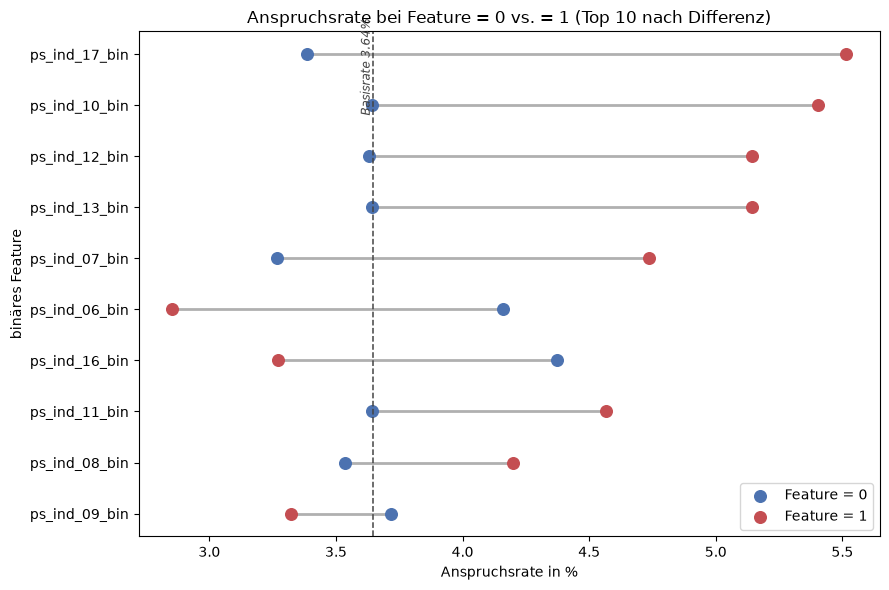

In [22]:
# visualisierung

top  = bin_analyse.sort_values("differenz").tail(10)   # aufsteigend -> größte oben
base = train["target"].mean()
y = np.arange(len(top))

fig, ax = plt.subplots(figsize=(9, 6))
ax.hlines(y, top["rate_bei_0"]*100, top["rate_bei_1"]*100, color="#B0B0B0", lw=2, zorder=1)
ax.scatter(top["rate_bei_0"]*100, y, color="#4C72B0", s=70, zorder=2, label="Feature = 0")
ax.scatter(top["rate_bei_1"]*100, y, color="#C44E52", s=70, zorder=2, label="Feature = 1")

ax.axvline(base*100, ls="--", color="#444", lw=1.1)
ax.text(base*100, len(top)-0.3, f"Basisrate {base:.2%}", rotation=90,
        ha="right", va="top", fontsize=8.5, color="#444", style="italic")

ax.set_yticks(y); ax.set_yticklabels(top.index)
ax.set_title("Anspruchsrate bei Feature = 0 vs. = 1 (Top 10 nach Differenz)")
ax.set_xlabel("Anspruchsrate in %"); ax.set_ylabel("binäres Feature")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

In [23]:
# ------------- NACHTRAG ---------------

# missing values vs. target (sagen die Fehlwerte etwas aus?)

baseline = train["target"].mean()   # Grundrate über alle Zeilen

# nur Features, die überhaupt fehlende Werte haben
miss_cols = train.columns[train.isna().any()].drop("target", errors="ignore")

rows = []
for col in miss_cols:
    is_missing = train[col].isna()
    rows.append({
        "feature":      col,
        "n_missing":    int(is_missing.sum()),
        "rate_missing": train.loc[is_missing,  "target"].mean(),  # Ziel-Rate wenn fehlt
        "rate_present": train.loc[~is_missing, "target"].mean(),  # Ziel-Rate wenn vorhanden
    })

miss_vs_target = (pd.DataFrame(rows)
                  .assign(lift=lambda d: d["rate_missing"] / baseline)  # relativ zur Grundrate
                  .sort_values("rate_missing", ascending=False)
                  .set_index("feature"))

print(f"Grundrate (baseline): {baseline:.4%}")

# hübsch anzeigen (Prozent gerundet)
miss_vs_target.assign(
    rate_missing=(miss_vs_target["rate_missing"] * 100).round(3),
    rate_present=(miss_vs_target["rate_present"] * 100).round(3),
    lift=miss_vs_target["lift"].round(2),
)

Grundrate (baseline): 3.6448%


,n_missing,rate_missing,rate_present,lift
feature,,,,
ps_ind_04_cat,83,39.759,3.640,10.91
ps_car_01_cat,107,31.776,3.640,8.72
ps_ind_02_cat,216,18.519,3.639,5.08
ps_car_09_cat,569,9.139,3.639,2.51
ps_ind_05_cat,5809,8.332,3.599,2.29
ps_car_07_cat,11489,7.816,3.563,2.14
ps_car_14,42620,4.043,3.614,1.11
ps_car_03_cat,411231,3.271,4.481,0.90
ps_car_05_cat,266551,3.171,4.029,0.87


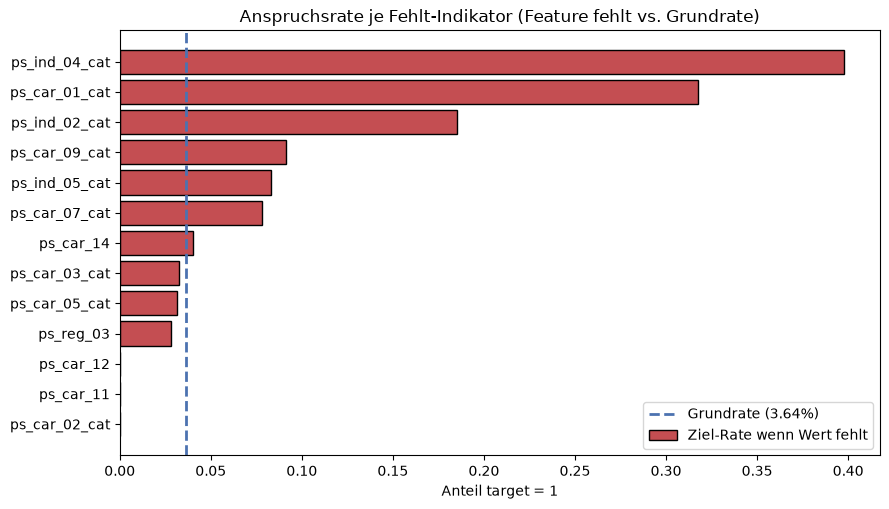

In [45]:
# ------------- NACHTRAG ---------------

# visualisierung

# Ziel-Rate je Fehlt-Indikator, (Grundrate als gestrichelte Linie)
order = miss_vs_target.sort_values("rate_missing")

fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(order))))
ax.barh(order.index, order["rate_missing"], color="#C44E52", edgecolor="black",
        label="Ziel-Rate wenn Wert fehlt")
ax.axvline(baseline, color="#4C72B0", linestyle="--", linewidth=2,
           label=f"Grundrate ({baseline:.2%})")

ax.set_title("Anspruchsrate je Fehlt-Indikator (Feature fehlt vs. Grundrate)")
ax.set_xlabel("Anteil target = 1")
ax.legend()
plt.tight_layout()
plt.show()

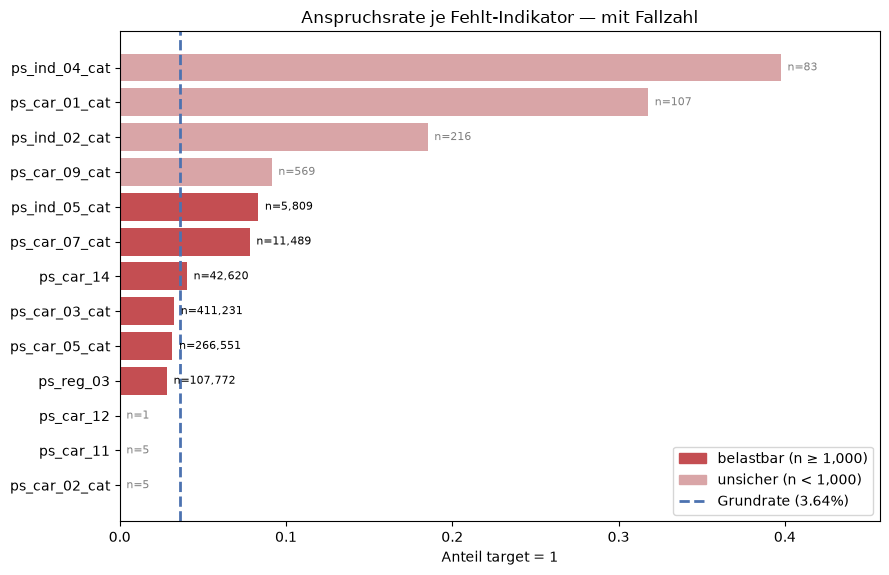

In [25]:
# ─────────────────────────────────────────────────────────────
# Fehlt-Indikator vs. target — jetzt mit n_missing sichtbar
# Idee: Rate nur dort belastbar, wo genug Fehlwerte vorliegen.
# ─────────────────────────────────────────────────────────────

MIN_MISSING = 1000   # Schwelle analog zu by_n[by_n["n"] >= 1000]

order = miss_vs_target.sort_values("rate_missing")
reliable = order["n_missing"] >= MIN_MISSING   # True = belastbar, False = Rauschen

fig, ax = plt.subplots(figsize=(9, max(3, 0.45 * len(order))))

# belastbare Features kräftig, unsichere blass
colors = ["#C44E52" if r else "#D9A5A7" for r in reliable]
bars = ax.barh(order.index, order["rate_missing"], color=colors)

ax.axvline(baseline, color="#4C72B0", linestyle="--", linewidth=2,
           label=f"Grundrate ({baseline:.2%})")

# n_missing an jeden Balken schreiben
for bar, n, r in zip(bars, order["n_missing"], reliable):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
            f"n={n:,}", va="center", ha="left",
            fontsize=8, color="black" if r else "gray")

# Legenden-Einträge für kräftig/blass
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#C44E52", label=f"belastbar (n ≥ {MIN_MISSING:,})"),
    Patch(color="#D9A5A7", label=f"unsicher (n < {MIN_MISSING:,})"),
    plt.Line2D([0], [0], color="#4C72B0", linestyle="--", linewidth=2,
               label=f"Grundrate ({baseline:.2%})"),
], loc="lower right")

ax.set_title("Anspruchsrate je Fehlt-Indikator — mit Fallzahl")
ax.set_xlabel("Anteil target = 1")
ax.set_xlim(0, order["rate_missing"].max() * 1.15)   # Platz für Labels
plt.tight_layout()
plt.show()

In [26]:
# Nur belastbare Features, nach Abweichung von der Grundrate sortiert
reliable_tbl = (miss_vs_target[miss_vs_target["n_missing"] >= MIN_MISSING]
                .assign(abw_ppt=lambda d: (d["rate_missing"] - baseline) * 100)  # Abweichung in %-Punkten
                .sort_values("abw_ppt", key=abs, ascending=False))

reliable_tbl.assign(
    rate_missing=(reliable_tbl["rate_missing"] * 100).round(3),
    rate_present=(reliable_tbl["rate_present"] * 100).round(3),
    abw_ppt=reliable_tbl["abw_ppt"].round(3),
    lift=reliable_tbl["lift"].round(2),
)

,n_missing,rate_missing,rate_present,lift,abw_ppt
feature,,,,,
ps_ind_05_cat,5809,8.332,3.599,2.29,4.687
ps_car_07_cat,11489,7.816,3.563,2.14,4.171
ps_reg_03,107772,2.839,3.823,0.78,-0.805
ps_car_05_cat,266551,3.171,4.029,0.87,-0.474
ps_car_14,42620,4.043,3.614,1.11,0.398
ps_car_03_cat,411231,3.271,4.481,0.90,-0.374


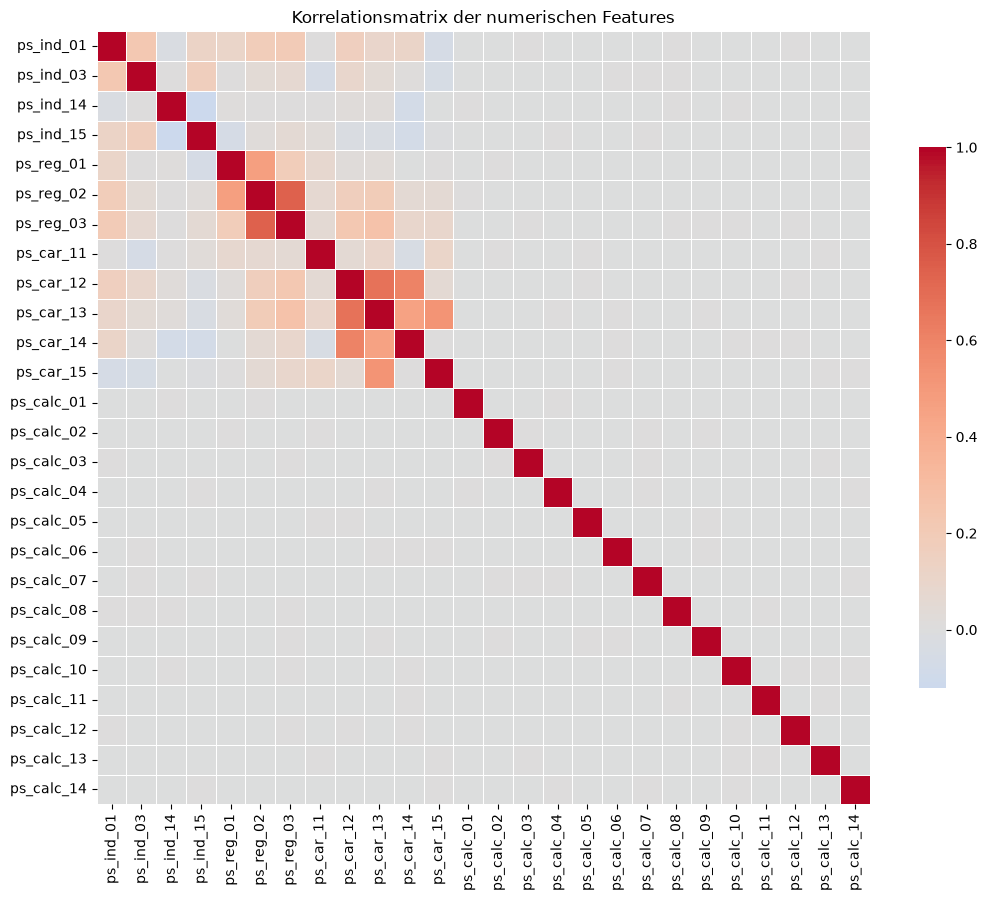

In [27]:
# Korrelationsmatrix berechnen
corr = train[num_cols].corr()

# Figure und Achsen erstellen
fig, ax = plt.subplots(figsize=(11, 9))

# Heatmap zeichnen
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .7},
    ax=ax
)

# Titel hinzufügen
ax.set_title("Korrelationsmatrix der numerischen Features")

# Layout optimieren
plt.tight_layout()

# Grafik anzeigen
plt.show()

In [28]:
# Sonderfall: ps_calc (da wenig informativ)

calc_cols = meta[meta.group == "calc"].index.tolist()

calc_corr = (train[calc_cols]
             .corrwith(train["target"])
             .abs()
             .sort_values(ascending=False))
calc_corr.head(10)


ps_calc_03        0.001907
ps_calc_01        0.001782
ps_calc_19_bin    0.001744
ps_calc_14        0.001362
ps_calc_02        0.001360
ps_calc_12        0.001133
ps_calc_20_bin    0.001072
ps_calc_10        0.001061
ps_calc_08        0.001006
ps_calc_05        0.000771
dtype: float64

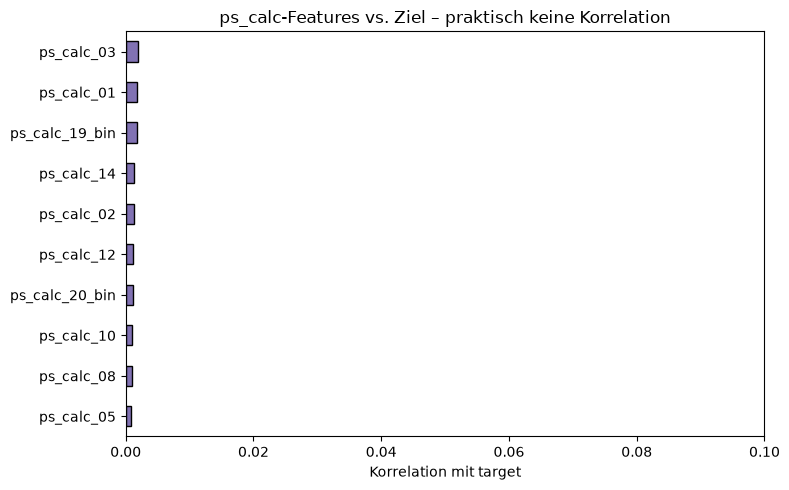

In [46]:
# visualisierung

ax = calc_corr.head(10).sort_values().plot(kind="barh", figsize=(8, 5), color="#8172B3", edgecolor="black")
ax.set_xlim(0, 0.10)
ax.set_xlabel("Korrelation mit target")
ax.set_title("ps_calc-Features vs. Ziel – praktisch keine Korrelation")
plt.tight_layout(); plt.show()